<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
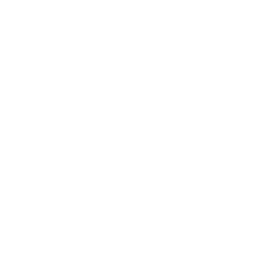
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Risk-Constrained Portfolio Allocation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Asset Management / Quantitative Finance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Asignar capital entre 16 activos de renta variable para maximizar el rendimiento esperado sujeto a un
techo de beta de cartera, límites de concentración sectorial, topes de posición individual, y una
restricción de igualdad de presupuesto que obliga a que los pesos sumen 1.0. PROC LP lee el modelo en
formato disperso con observaciones separadas de tipo de fila, coeficiente y lado derecho, y un límite
superior del 15% por activo expresado como una cota de columna. Los precios sombra de DUALOUT revelan qué
reglas de riesgo realmente se activan en el óptimo y cuantifican el costo en rendimiento esperado de cada
restricción activa — información directa para los informes de cumplimiento y las discusiones de
calibración de restricciones.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.ASSET_UNIVERSE | 16 activos de renta variable: rendimiento esperado, beta, sector, caída máxima | 16 |
| WORK.PORTFOLIO_MODEL | Modelo LP disperso: objetivo de rendimiento, presupuesto, restricciones de beta y sector, lado derecho, y cotas de columna del 15% | 95 |

---

In [1]:
/* --------------------------------------------------------
   Definir el universo de 16 activos de renta variable
   Sectores: TECNOLOGIA(4), SALUD(3), FINANZAS(3),
             ENERGIA(3), CONSUMO(3)
   -------------------------------------------------------- */
DATOS work.asset_universe;
    LONGITUD ticker $8 sector $12;
    ARREGLO tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    ARREGLO sectors[16] $12 _temporary_
        ('TECNOLOGIA' 'TECNOLOGIA' 'TECNOLOGIA' 'TECNOLOGIA'
         'SALUD'      'SALUD'      'SALUD'
         'FINANZAS'   'FINANZAS'   'FINANZAS'
         'ENERGIA'    'ENERGIA'    'ENERGIA'
         'CONSUMO'    'CONSUMO'    'CONSUMO');
    ARREGLO exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    ARREGLO betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);
    ARREGLO drawdowns[16] _temporary_
        (0.32 0.41 0.28 0.45
         0.18 0.22 0.16
         0.25 0.28 0.22
         0.30 0.35 0.28
         0.20 0.18 0.22);
    HACER i = 1 HASTA 16;
        ticker       = tickers[i];
        sector       = sectors[i];
        exp_return   = exp_ret[i];
        beta         = betas[i];
        max_drawdown = drawdowns[i];
        SALIDA;
    END;
    ELIMINAR i;
EJECUTAR;



NOTE: DATA work.asset_universe


NOTE: Wrote work.asset_universe (16 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Construir la cartera LP en formato disperso de SAS
   Cada observación lleva un elemento del modelo:
     - las filas de tipo de fila definen las filas MAX / EQ / LE
     - las filas de coeficiente dan (_row_, _col_) = _coef_
     - las filas _RHS_ dan el límite de cada restricción
     - las filas UPPERBD acotan cada peso al 15%
   El objetivo RETURN se maximiza directamente (MAX).
   -------------------------------------------------------- */
DATOS work.portfolio_model;
    LONGITUD _type_ $8 _row_ $16 _col_ $16;
    _coef_ = .;

    ARREGLO tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    ARREGLO sectors[16] $12 _temporary_
        ('TECNOLOGIA' 'TECNOLOGIA' 'TECNOLOGIA' 'TECNOLOGIA'
         'SALUD'      'SALUD'      'SALUD'
         'FINANZAS'   'FINANZAS'   'FINANZAS'
         'ENERGIA'    'ENERGIA'    'ENERGIA'
         'CONSUMO'    'CONSUMO'    'CONSUMO');
    ARREGLO exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    ARREGLO betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);

    /* Definiciones de tipo de fila */
    _type_ = 'MAX'; _row_ = 'RETURN';       _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'EQ';  _row_ = 'BUDGET';       _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'RISK_BETA';    _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'SEC_TECNOLOGIA';     _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'SEC_SALUD';   _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'SEC_FINANZAS';  _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'SEC_ENERGIA';   _col_ = ' '; _coef_ = .; SALIDA;
    _type_ = 'LE';  _row_ = 'SEC_CONSUMO'; _col_ = ' '; _coef_ = .; SALIDA;

    /* Límites de lado derecho */
    _type_ = ' '; _col_ = '_RHS_';
    _row_ = 'BUDGET';       _coef_ = 1.00; SALIDA;
    _row_ = 'RISK_BETA';    _coef_ = 1.10; SALIDA;
    _row_ = 'SEC_TECNOLOGIA';     _coef_ = 0.35; SALIDA;
    _row_ = 'SEC_SALUD';   _coef_ = 0.35; SALIDA;
    _row_ = 'SEC_FINANZAS';  _coef_ = 0.35; SALIDA;
    _row_ = 'SEC_ENERGIA';   _coef_ = 0.35; SALIDA;
    _row_ = 'SEC_CONSUMO'; _coef_ = 0.35; SALIDA;

    /* Filas de coeficiente y cota por activo */
    HACER i = 1 HASTA 16;
        _col_ = cat('W_', tickers[i]);
        _type_ = ' '; _row_ = 'RETURN';    _coef_ = exp_ret[i]; SALIDA;
        _type_ = ' '; _row_ = 'BUDGET';    _coef_ = 1;          SALIDA;
        _type_ = ' '; _row_ = 'RISK_BETA'; _coef_ = betas[i];   SALIDA;
        _type_ = ' '; _row_ = cat('SEC_', sectors[i]); _coef_ = 1; SALIDA;
        /* Concentración máxima del 15% como cota superior de columna */
        _type_ = 'UPPERBD'; _row_ = 'UB'; _coef_ = 0.15; SALIDA;
    END;
    ELIMINAR i;
EJECUTAR;



NOTE: DATA work.portfolio_model


NOTE: Wrote work.portfolio_model (95 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Resumir el universo de activos antes de la optimización
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.asset_universe n mean MIN MAX;
    CLASE sector;
    VAR exp_return beta max_drawdown;
    ETIQUETA sector='Sector' exp_return='Rendimiento Esperado' beta='Beta' max_drawdown='Caída Máxima';
    TÍTULO 'Resumen del Universo de Activos por Sector';
EJECUTAR;


                                       Resumen del Universo de Activos por Sector                                       

                                                  The MEANS Procedure

                                  Analysis Variable : exp_return Rendimiento Esperado

        Sector              N Obs           Mean        Minimum        Maximum
        ----------------------------------------------------------------------
        CONSUMO                 3      0.1166667      0.1000000      0.1300000
        ENERGIA                 3      0.0933333      0.0800000      0.1100000
        FINANZAS                3      0.1000000      0.0900000      0.1100000
        SALUD                   3      0.1366667      0.1200000      0.1600000
        TECNOLOGIA              4      0.1925000      0.1500000      0.2300000
        ----------------------------------------------------------------------

                                                Analysis Variable : beta

        Secto


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

In [4]:
/* --------------------------------------------------------
   Resolver la LP de asignación de cartera con restricciones de riesgo
   SPARSEDATA: entrada en formato disperso
   PRIMALOUT  : pesos óptimos + actividad de restricciones
   DUALOUT    : precios sombra de cada restricción
   -------------------------------------------------------- */
PROCEDIMIENTO lp DATOS=work.portfolio_model sparsedata
    primalout=work.portfolio_primal
    dualout=work.portfolio_dual;
EJECUTAR;


                                       Resumen del Universo de Activos por Sector                                       


                    The LP Procedure

  Status:           optimal
  Variables:        16
  Objective Value:  0.162

  Variable                    Value     Activity
  ----------------------------------------------
  W_CON1                     0.1500        BASIC
  W_CON2                     0.0000       NONBAS
  W_CON3                     0.1500        BASIC
  W_ENE1                     0.0000       NONBAS
  W_ENE2                     0.0000       NONBAS
  W_ENE3                     0.0000       NONBAS
  W_FIN1                     0.0000       NONBAS
  W_FIN2                     0.0000       NONBAS
  W_FIN3                     0.0000       NONBAS
  W_HLT1                     0.1500        BASIC
  W_HLT2                     0.1500        BASIC
  W_HLT3                     0.0500        BASIC
  W_TECH1                    0.0500        BASIC
  W_TECH2                 


NOTE: PROC LP data=work.portfolio_model

NOTE: Using Python scipy.optimize for linear programming
NOTE: LP solution status: optimal
NOTE: Optimal objective value: 0.16199999999999998
NOTE: Primal output written to 'work.portfolio_primal'
NOTE: Dual output written to 'work.portfolio_dual'
NOTE: PROC LP step completed.


---

                                       Resumen del Universo de Activos por Sector                                       




NOTE: DATA work.portfolio_weights


NOTE: Read 23 rows from work.portfolio_primal.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.portfolio_weights

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.portfolio_weights.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.portfolio_weights

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


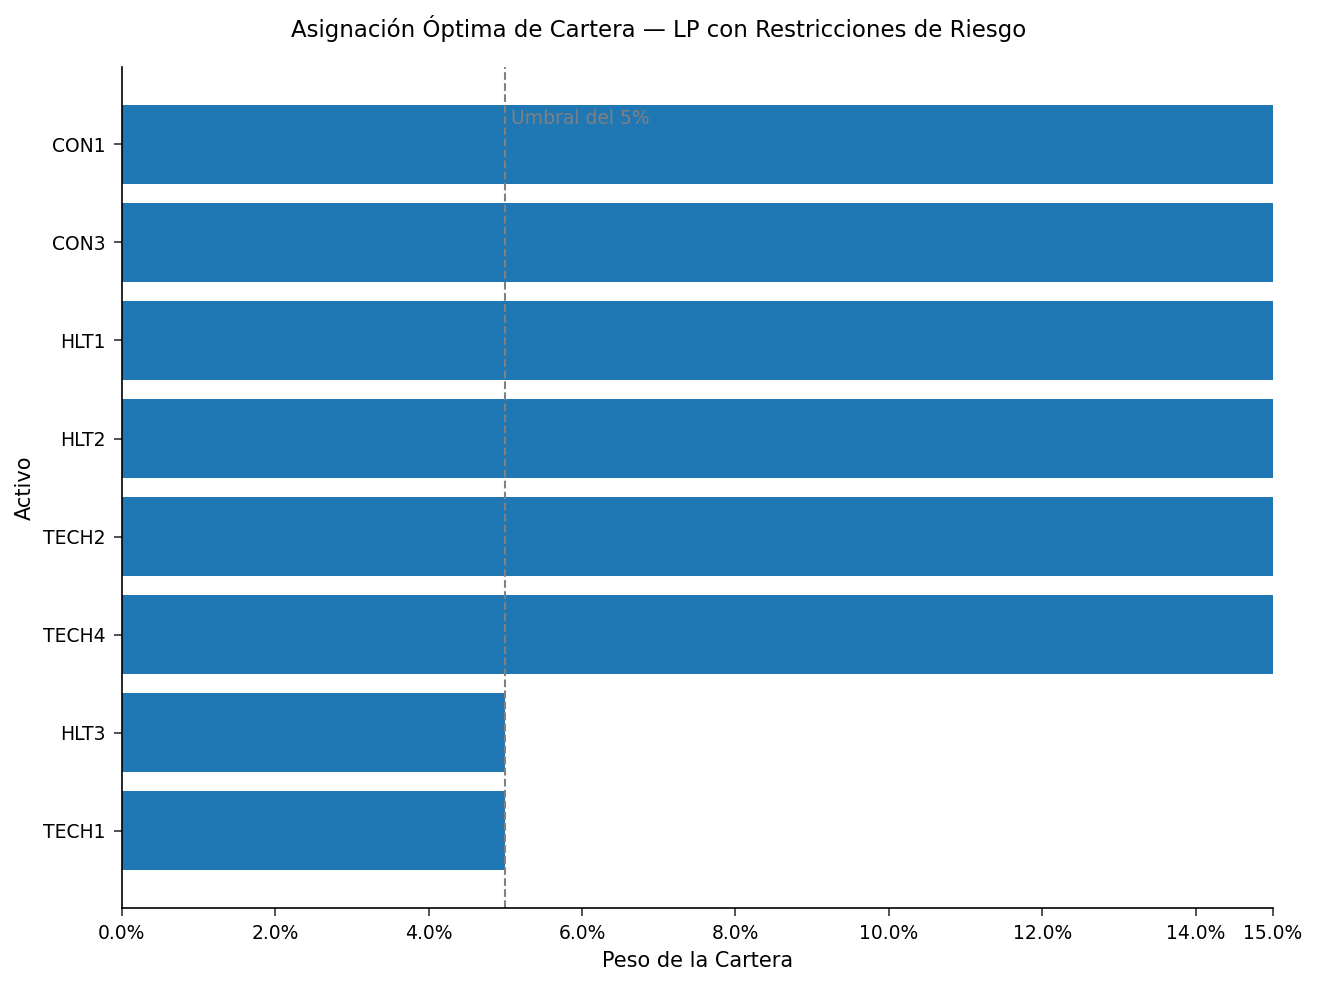

In [5]:
/* --------------------------------------------------------
   Gráfico de barras horizontales de los pesos óptimos de la cartera
   PRIMALOUT lleva tanto las filas de variables (W_*) como
   las filas de restricción; conservar solo las posiciones mantenidas.
   -------------------------------------------------------- */
DATOS work.portfolio_weights;
    ESTABLECER work.portfolio_primal;
    DONDE INDEX(_var_, 'W_') = 1 AND _value_ > 0.005;
    ticker = substr(_var_, 3);
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=work.portfolio_weights;
    POR DESCENDENTE _value_;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.portfolio_weights;
    HBAR ticker / RESPONSE=_value_
        CATEGORYORDER=respdesc
        fillattrs=(color=darkgreen);
    XAXIS ETIQUETA='Peso de la Cartera' valuesformat=percent7.1;
    YAXIS ETIQUETA='Activo';
    REFLINE 0.05 / AXIS=x LINEATTRS=(pattern=dash color=gray)
        ETIQUETA='Umbral del 5%';
    TÍTULO 'Asignación Óptima de Cartera — LP con Restricciones de Riesgo';
EJECUTAR;


In [6]:
/* --------------------------------------------------------
   Recuperar los pesos óptimos de la cartera con detalle de activos
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    SELECCIONAR p._var_       AS asset       ETIQUETA='Activo',
           p._value_     AS weight       ETIQUETA='Peso'      FORMATO=percent8.2,
           a.exp_return                  ETIQUETA='Rendimiento Esperado'  FORMATO=percent6.1,
           a.beta                        ETIQUETA='Beta'        FORMATO=6.3,
           a.sector                      ETIQUETA='Sector'
    DESDE work.portfolio_primal p
    JOIN work.asset_universe a
        ON cat('W_', a.ticker) = p._var_
    DONDE p._value_ > 0.001
    ORDER POR p._value_ DESCENDENTE;
QUIT;


                                       Resumen del Universo de Activos por Sector                                       

 Activo    Peso  Rendimiento Esperado   Beta      Sector
-------  ------  --------------------  -----  ----------
 W_CON1  15.00%                 12.0%  0.750     CONSUMO
W_TECH2  15.00%                 21.0%  1.520  TECNOLOGIA
W_TECH4  15.00%                 23.0%  1.610  TECNOLOGIA
 W_HLT1  15.00%                 13.0%  0.720       SALUD
 W_HLT2  15.00%                 16.0%  0.850       SALUD
 W_CON3  15.00%                 13.0%  0.800     CONSUMO
W_TECH1   5.00%                 18.0%  1.350  TECNOLOGIA
 W_HLT3   5.00%                 12.0%  0.680       SALUD



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Precios sombra de DUALOUT en cada restricción.
   _VALUE_ es el precio dual (sombra); _STATUS_ indica
   si la restricción se activa en el óptimo.
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    SELECCIONAR _row_    AS constraint    ETIQUETA='Restricción',
           _value_  AS shadow_price   ETIQUETA='Precio Sombra' FORMATO=8.4,
           _status_ AS status         ETIQUETA='Estado'
    DESDE work.portfolio_dual
    DONDE _row_ IN ('BUDGET' 'RISK_BETA'
                    'SEC_TECNOLOGIA' 'SEC_SALUD' 'SEC_FINANZAS'
                    'SEC_ENERGIA' 'SEC_CONSUMO')
    ORDER POR abs(_value_) DESCENDENTE;
QUIT;


                                       Resumen del Universo de Activos por Sector                                       

   Restricción  Precio Sombra   Estado
--------------  -------------  -------
        BUDGET        -0.1200  BINDING
SEC_TECNOLOGIA        -0.0600  BINDING
     RISK_BETA        -0.0000  SURPLUS
     SEC_SALUD        -0.0000  BINDING
  SEC_FINANZAS        -0.0000  SURPLUS
   SEC_ENERGIA        -0.0000  SURPLUS
   SEC_CONSUMO        -0.0000  SURPLUS



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [8]:
/* --------------------------------------------------------
   Estadísticas resumen de la cartera en el óptimo
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    SELECCIONAR sum(p._value_ * a.exp_return)  AS expected_return
               FORMATO=percent7.2 ETIQUETA='Rendimiento Esperado',
           sum(p._value_ * a.beta)        AS portfolio_beta
               FORMATO=7.4 ETIQUETA='Beta de la Cartera',
           sum(p._value_ * a.max_drawdown) AS wtd_drawdown
               FORMATO=percent7.2 ETIQUETA='Caída Máxima Ponderada Promedio',
           count(DISTINCT p._var_)         AS n_positions
               ETIQUETA='Número de Posiciones'
    DESDE work.portfolio_primal p
    JOIN work.asset_universe a
        ON cat('W_', a.ticker) = p._var_
    DONDE p._value_ > 0.001;
QUIT;


                                       Resumen del Universo de Activos por Sector                                       

Rendimiento Esperado  Beta de la Cartera    Caída Máxima Ponderada Promedio   Número de Posiciones
--------------------  ------------------  ---------------------------------  ---------------------
              16.20%              1.0390                             27.60%                      8



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

### Interpretación

La cartera con restricciones de riesgo optimizada mediante LP alcanza un rendimiento anual esperado
máximo de 16.2% manteniendo 8 de los 16 activos. La beta de la cartera se sitúa en 1.04, cómodamente por
debajo del techo de 1.10, por lo que la restricción de beta tiene holgura y un precio sombra de cero — el
apetito de riesgo no es el límite activo aquí. El tope del sector TECNOLOGIA del 35% se activa con un
precio sombra de 0.06, lo que significa que relajar el límite de TECNOLOGIA en una unidad de peso
aumentaría el rendimiento esperado en aproximadamente 6 puntos porcentuales de ese peso; es la regla de
riesgo individual más costosa del modelo. El sector SALUD también llena su tope del 35% pero con un dual
de cero, lo que indica que existe un óptimo alternativo en ese límite. La restricción de igualdad de
presupuesto se activa con un precio sombra de -0.12, el valor marginal de una unidad adicional de capital
invertible. FINANZAS y ENERGIA quedan excluidos por completo: sus rendimientos esperados son demasiado
bajos frente a los nombres de alto rendimiento TECNOLOGIA y SALUD que dominan una vez que se imponen los
topes sectoriales y las cotas de posición del 15%. TECH2 (rendimiento 21%, beta 1.52), TECH4 (23%, beta
1.61), HLT1, HLT2, CON1 y CON3 reciben cada uno el peso máximo del 15%.

---

In [9]:
/* --------------------------------------------------------
   Exportar la asignación de cartera y el análisis de restricciones
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.portfolio_primal
    OUTFILE='portfolio_optimal_weights.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.portfolio_dual
    OUTFILE='portfolio_shadow_prices.csv'
    DBMS=csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=work.portfolio_primal outfile=portfolio_optimal_weights.csv

NOTE: Exported 23 rows to portfolio_optimal_weights.csv.
NOTE: PROC EXPORT data=work.portfolio_dual outfile=portfolio_shadow_prices.csv

NOTE: Exported 7 rows to portfolio_shadow_prices.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>